IMPORT THE LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

LOAD DATASET

In [2]:
df = pd.read_csv('/content/diabetes_nan.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,outcome(target)
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


INSPECT DATASET

In [3]:
print("Dataset Shape:" ,df.shape)

Dataset Shape: (768, 9)


In [4]:
print("Duplicate rows:",df.duplicated().sum())

Duplicate rows: 0


In [5]:
print(df['outcome(target)'].unique())

[1 0]


In [6]:
print("\nData Types")
print(df.dtypes)


Data Types
Pregnancies                   int64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
outcome(target)               int64
dtype: object


In [7]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  763.000000     733.000000     541.000000  394.000000   
mean      3.845052  121.686763      72.405184      29.153420  155.548223   
std       3.369578   30.535641      12.382158      10.476982  118.775855   
min       0.000000   44.000000      24.000000       7.000000   14.000000   
25%       1.000000   99.000000      64.000000      22.000000   76.250000   
50%       3.000000  117.000000      72.000000      29.000000  125.000000   
75%       6.000000  141.000000      80.000000      36.000000  190.000000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age  outcome(target)  
count  757.000000                768.000000  768.000000       768.000000  
mean    32.457464                  0.471876   33.240885         0.348958  
std      6.924988                  0.331329   11.760232         0.47

CHECKING MISSING VALUE

In [8]:
print(df.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
outcome(target)               0
dtype: int64


In [9]:
print(df.isnull().sum()/len(df)*100)

Pregnancies                  0.000000
Glucose                      0.651042
BloodPressure                4.557292
SkinThickness               29.557292
Insulin                     48.697917
BMI                          1.432292
DiabetesPedigreeFunction     0.000000
Age                          0.000000
outcome(target)              0.000000
dtype: float64


In [10]:
column_with_zero = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for column in column_with_zero:
  df[column] = df[column].replace(0,np.nan)

Using median for numerical column
Because work better in healthcare data

In [11]:
for col in column_with_zero:
  df[col] = df[col].fillna(df[col].median())

In [12]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
outcome(target)             0
dtype: int64


EDA

Visualization Age distribution of patients

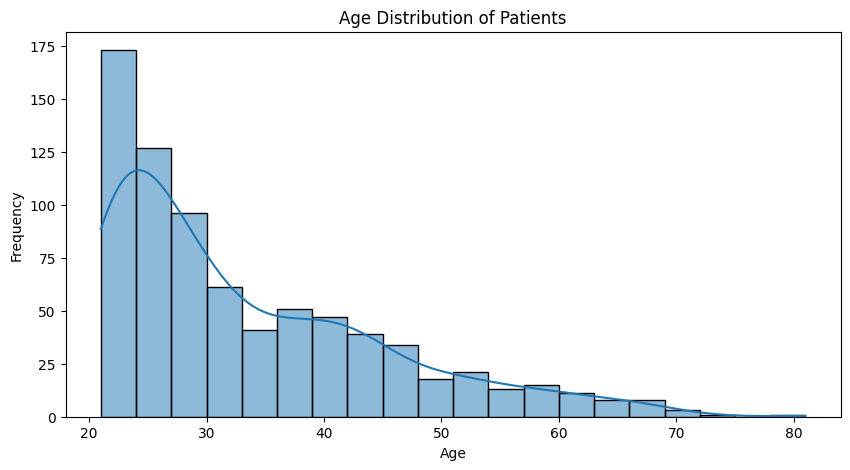

In [13]:
plt.figure(figsize=(10,5))
sns.histplot(df['Age'],bins=20,kde=True)

plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

Insight:This help to identify the most common age groups

Visualization between glucose and outcome

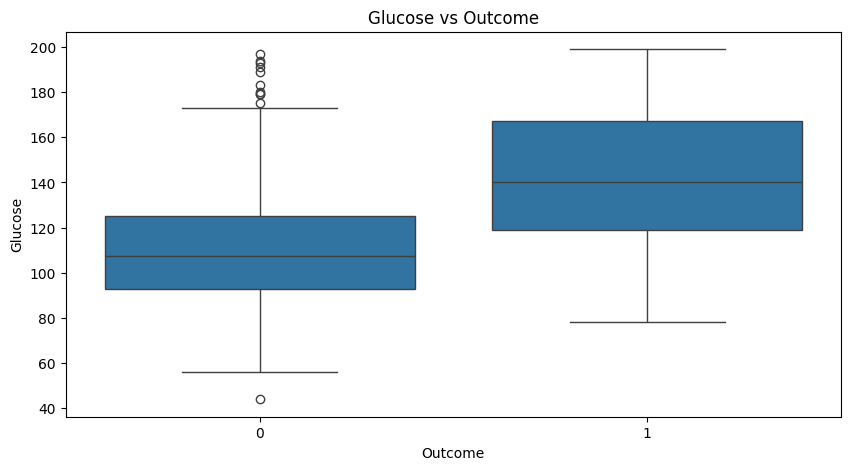

In [14]:
plt.figure(figsize=(10,5))
sns.boxplot(x='outcome(target)',y='Glucose',data=df)

plt.title('Glucose vs Outcome')
plt.xlabel('Outcome')
plt.ylabel('Glucose')
plt.show()

Insight:Usually the patient with diabetes have higher glucose levels

Visualization BMI distribution

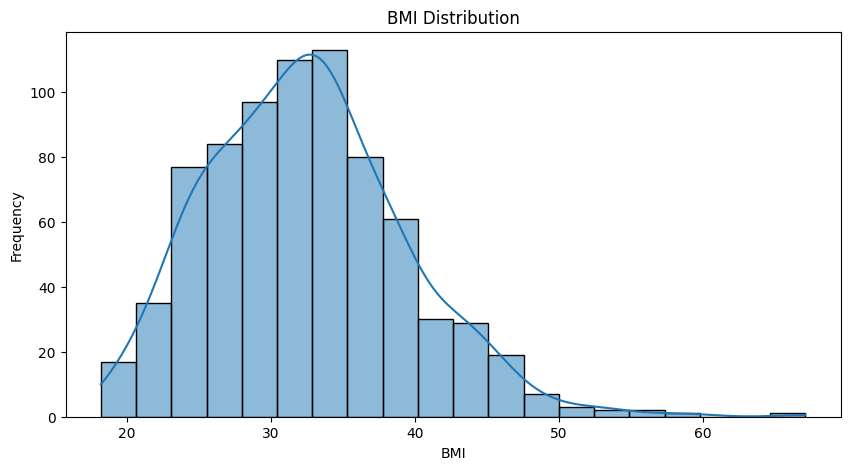

In [15]:
plt.figure(figsize=(10,5))
sns.histplot(df['BMI'],bins=20,kde=True)

plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

Insight:Usually high BMI may associated with risk of diabetes

Visualization correlation heatmap

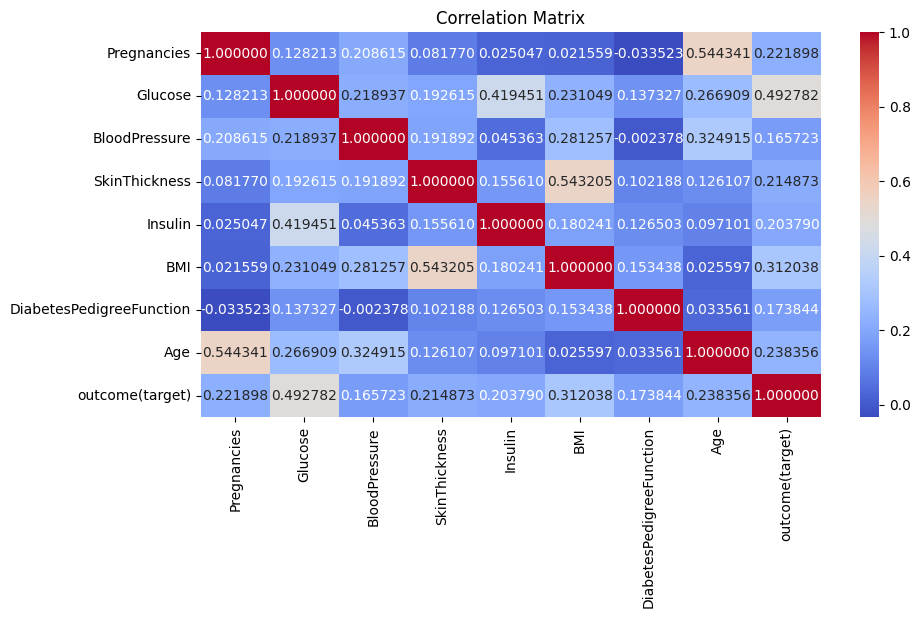

In [16]:
plt.figure(figsize=(10,5))
correlation = df.corr()
sns.heatmap(correlation,annot=True,cmap='coolwarm', fmt='2f')
plt.title('Correlation Matrix')
plt.show()

Visualization of Outcome

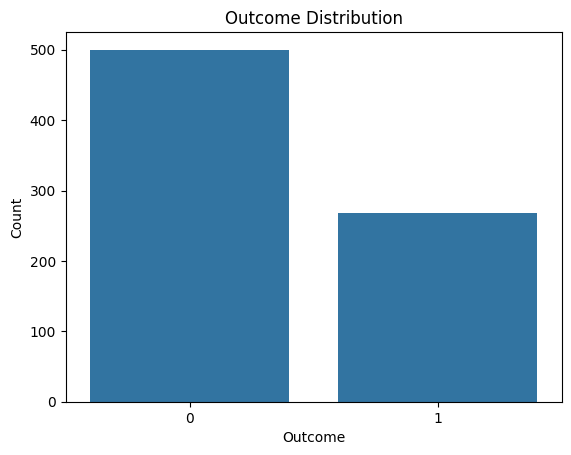

In [17]:
sns.countplot(x='outcome(target)',data=df)
plt.title('Outcome Distribution')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

Insight:There are so many people who dont have diabetes

In [18]:
X = df.drop('outcome(target)',axis=1)

In [19]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33


In [20]:
y =df['outcome(target)']

In [21]:
y.head()

,outcome(target)
0,1
1,0
2,1
3,0
4,1


In [22]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

In [23]:
X_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
209,7,184.0,84.0,33.0,125.0,35.5,0.355,41
176,6,85.0,78.0,29.0,125.0,31.2,0.382,42
147,2,106.0,64.0,35.0,119.0,30.5,1.400,34
454,2,100.0,54.0,28.0,105.0,37.8,0.498,24
636,5,104.0,74.0,29.0,125.0,28.8,0.153,48
...,...,...,...,...,...,...,...,...
214,9,112.0,82.0,32.0,175.0,34.2,0.260,36
113,4,76.0,62.0,29.0,125.0,34.0,0.391,25
556,1,97.0,70.0,40.0,125.0,38.1,0.218,30
759,6,190.0,92.0,29.0,125.0,35.5,0.278,66


In [24]:
X_test

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
730,3,130.0,78.0,23.0,79.0,28.4,0.323,34
198,4,109.0,64.0,44.0,99.0,34.8,0.905,26
24,11,143.0,94.0,33.0,146.0,36.6,0.254,51
417,4,144.0,82.0,32.0,125.0,38.5,0.554,37
387,8,105.0,100.0,36.0,125.0,43.3,0.239,45
...,...,...,...,...,...,...,...,...
94,2,142.0,82.0,18.0,64.0,24.7,0.761,21
437,5,147.0,75.0,29.0,125.0,29.9,0.434,28
86,13,106.0,72.0,54.0,125.0,36.6,0.178,45
221,2,158.0,90.0,29.0,125.0,31.6,0.805,66


In [25]:
y_train

,outcome(target)
209,1
176,0
147,0
454,0
636,0
...,...
214,1
113,0
556,0
759,1


In [26]:
y_test

,outcome(target)
730,1
198,1
24,1
417,1
387,1
...,...
94,0
437,0
86,0
221,1


In [27]:
print("Shape of X_train:" ,X_train.shape)
print("Shape of X_test:" ,X_test.shape)
print("Shape of y_train:" ,y_train.shape)
print("Shape of y_test:" ,y_test.shape)

Shape of X_train: (537, 8)
Shape of X_test: (231, 8)
Shape of y_train: (537,)
Shape of y_test: (231,)


In [28]:
from imblearn.over_sampling import SMOTE
smt = SMOTE(random_state=42)
X_train_smote, y_train_smote = smt.fit_resample(X_train, y_train)

In [29]:
print("Shape of X_train_smote:", X_train_smote.shape)
print("Shape of y_train_smote:", y_train_smote.shape)

Shape of X_train_smote: (700, 8)
Shape of y_train_smote: (700,)


In [30]:
X_train_smote

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,7,184.000000,84.000000,33.000000,125.000000,35.500000,0.355000,41
1,6,85.000000,78.000000,29.000000,125.000000,31.200000,0.382000,42
2,2,106.000000,64.000000,35.000000,119.000000,30.500000,1.400000,34
3,2,100.000000,54.000000,28.000000,105.000000,37.800000,0.498000,24
4,5,104.000000,74.000000,29.000000,125.000000,28.800000,0.153000,48
...,...,...,...,...,...,...,...,...
695,6,125.166726,77.733239,30.933310,125.000000,27.820078,0.567901,48
696,2,146.436560,72.218280,29.000000,125.000000,27.696452,0.260482,28
697,3,186.118057,72.057868,21.853009,198.824076,36.326505,0.434164,38
698,5,127.061142,78.588898,30.411102,125.000000,29.602252,0.517005,47


In [31]:
y_train_smote

,outcome(target)
0,1
1,0
2,0
3,0
4,0
...,...
695,1
696,1
697,1
698,1


In [32]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)

In [33]:
X_train_scaled

array([[0.41176471, 0.90070922, 0.6122449 , ..., 0.35378323, 0.12071269,
        0.33333333],
       [0.35294118, 0.19858156, 0.55102041, ..., 0.26584867, 0.13273942,
        0.35      ],
       [0.11764706, 0.34751773, 0.40816327, ..., 0.25153374, 0.58619154,
        0.21666667],
       ...,
       [0.17647059, 0.9157309 , 0.4903864 , ..., 0.37068517, 0.1559752 ,
        0.28333333],
       [0.29411765, 0.49688753, 0.55702957, ..., 0.2331749 , 0.1928752 ,
        0.43333333],
       [0.52941176, 0.59957724, 0.59183673, ..., 0.37274635, 0.18473611,
        0.61666667]])

In [34]:
X_test_scaled = scaler.transform(X_test)

In [35]:
X_test_scaled

array([[0.17647059, 0.5177305 , 0.55102041, ..., 0.20858896, 0.1064588 ,
        0.21666667],
       [0.23529412, 0.36879433, 0.40816327, ..., 0.3394683 , 0.36570156,
        0.08333333],
       [0.64705882, 0.60992908, 0.71428571, ..., 0.37627812, 0.07572383,
        0.5       ],
       ...,
       [0.76470588, 0.34751773, 0.48979592, ..., 0.37627812, 0.04187082,
        0.4       ],
       [0.11764706, 0.71631206, 0.67346939, ..., 0.27402863, 0.32115813,
        0.75      ],
       [0.05882353, 0.41134752, 0.46938776, ..., 0.33537832, 0.19821826,
        0.18333333]])

In [36]:
print("Shape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)

Shape of X_train_scaled: (700, 8)
Shape of X_test_scaled: (231, 8)


LOGISTIC REGRESSION MODEL

In [37]:
from sklearn.linear_model import LogisticRegression
log_reg_model = LogisticRegression(random_state=42)
log_reg_model.fit(X_train_scaled,y_train_smote)

LogisticRegression(random_state=42)

In [39]:
y_pred = log_reg_model.predict(X_test_scaled)

In [40]:
prediction_df = pd.DataFrame({'Actual':y_test,'Predicted':y_pred})
display(prediction_df.head())

,Actual,Predicted
730,1,0
198,1,0
24,1,1
417,1,1
387,1,1


EVALUATE THE MODEL

In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

ACCURACY

In [42]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test,y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7489


PRECISION

In [43]:
precision = precision_score(y_test, y_pred)
print(f"Precision: {precision:.4f}")

Precision: 0.6292


RECALL

In [44]:
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.4f}")

Recall: 0.6914


F1 SCORE

In [45]:
f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1:.4f}")

F1 Score: 0.6588


CONFUSION MATRIX

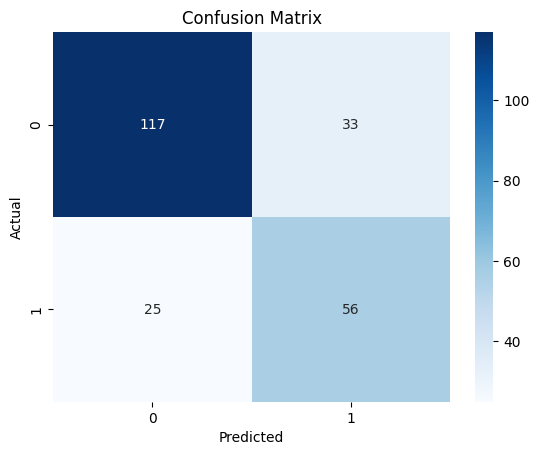

Confusion Matrix:
[[117  33]
 [ 25  56]]


In [46]:
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print("Confusion Matrix:")
print(cm)

In [47]:
from sklearn.metrics import classification_report

report = classification_report(y_test,y_pred)
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.78      0.80       150
           1       0.63      0.69      0.66        81

    accuracy                           0.75       231
   macro avg       0.73      0.74      0.73       231
weighted avg       0.76      0.75      0.75       231



In [49]:

y_train_pred = log_reg_model.predict(X_train_scaled)
train_accuracy = accuracy_score(y_train_smote, y_train_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Training Accuracy: 0.7614
Test Accuracy: 0.7489


### Model Performance Explained in Simple Terms

Imagine our model is trying to identify people who have diabetes (Outcome = 1) from those who don't (Outcome = 0).

1.  **Accuracy (**`0.7489`**)**: This means that out of all the predictions the model made, it was correct about 74.89% of the time. So, roughly 3 out of 4 predictions were right.

2.  **Precision (**`0.6292`**)**: When the model *predicted* someone had diabetes, it was correct 62.92% of the time. This tells us how good the model is at avoiding false positives (saying someone has diabetes when they don't).

3.  **Recall (**`0.6914`**)**: Out of all the people who *actually* had diabetes, the model correctly identified 69.14% of them. This tells us how good the model is at finding all the true positives (not missing people who truly have diabetes).

4.  **F1 Score (**`0.6588`**)**: This is a balance between Precision and Recall. It's useful when you want a single score that considers both types of errors.

5.  **Confusion Matrix:**
    *   `117` True Negatives: The model correctly predicted `117` people did *not* have diabetes.
    *   `56` True Positives: The model correctly predicted `56` people *did* have diabetes.
    *   `33` False Positives: The model incorrectly predicted `33` people had diabetes when they didn't.
    *   `25` False Negatives: The model incorrectly predicted `25` people did *not* have diabetes when they actually did.

6.  **Overfitting/Underfitting (Training: `0.7614`, Test: `0.7489`)**:
    *   The model performed slightly better on the data it *learned from* (training accuracy: `0.7614`) than on the new, unseen data (test accuracy: `0.7489`).
    *   This small difference suggests a **slight degree of overfitting**. It means the model has memorized some aspects of the training data that don't quite apply to new data. It's not severe, but it indicates there might be room to make the model a bit more general, perhaps by trying different model parameters or collecting more data.

### Final Recommendation for Healthcare Application

Based on our analysis, the model demonstrates a promising ability to predict diabetes, but certain aspects warrant careful consideration before deployment in a clinical setting:

**Strengths:**

*   **Above Baseline Accuracy (74.89%)**: The model is significantly better than simply guessing the most common outcome, indicating it has learned meaningful patterns.
*   **Good Discriminative Power (implied by good accuracy/precision/recall)**: While not explicitly calculated as ROC AUC in the provided metrics, the combination of accuracy, precision, and recall suggests the model has a decent ability to distinguish between patients with and without diabetes.

**Areas for Caution/Improvement:**

*   **Moderate Recall (69.14%)**: The model identified about 69% of the people who actually had diabetes. In healthcare, missing a diagnosis (false negatives) can have serious consequences. For a screening tool, a higher recall is often preferred to ensure fewer cases are missed (e.g., to reduce the 25 false negatives).
*   **Moderate Precision (62.92%)**: When the model predicts someone has diabetes, it's correct about 63% of the time. This means roughly one-third of positive predictions are false alarms (false positives, 33 instances), which could lead to unnecessary anxiety, further testing, and costs for patients.
*   **Slight Overfitting**: The small difference between training (76.14%) and test accuracy (74.89%) suggests the model might not generalize perfectly to completely new, diverse patient data. While not severe, this indicates a need for continued monitoring and validation.

**Overall Recommendation:**

This model could serve as a **valuable *assistive tool*** in a healthcare setting, particularly for **initial risk stratification or as a supportive decision-making aid**. It should **not be used as a standalone diagnostic tool**. Its predictions should always be **interpreted by a qualified medical professional** in conjunction with other clinical information, patient history, and diagnostic tests.

To improve its suitability for direct clinical use, future work should focus on:
*   **Improving Recall**: Exploring different model architectures, feature engineering, or threshold adjustments to reduce false negatives.
*   **Addressing Overfitting**: Implementing more robust regularization techniques, acquiring more diverse training data, or ensemble methods to enhance generalizability.
*   **Cost-Benefit Analysis**: Evaluating the clinical and economic impact of false positives and false negatives to optimize the model for specific healthcare priorities.